In [10]:
%matplotlib widget

from ipywidgets import interact
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

interactive(children=(IntSlider(value=0, description='m'), Output()), _dom_classes=('widget-interact',))

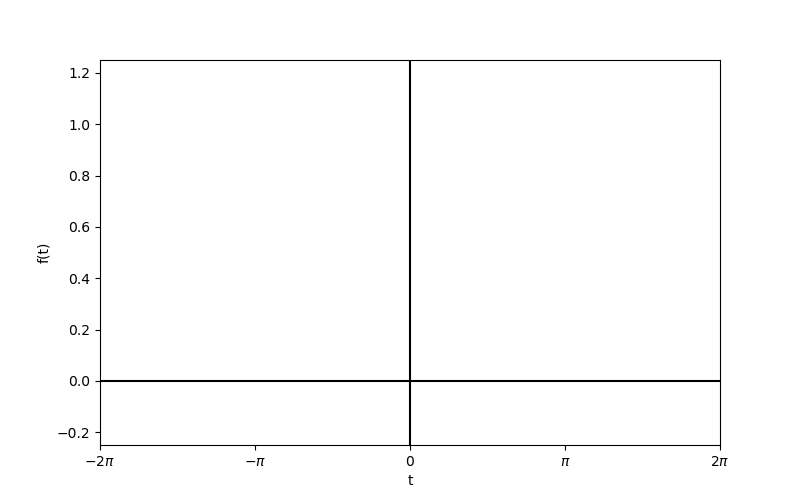

In [15]:
cycles = 5
A = 1
T = 2*np.pi


x = []

for i in range(0, 2*cycles, 2):  #skipping by 2 since pattern repeats every 2pi
    x.append(i * T/2)  # getting values of 0, 2pi, 4pi...
    x.append((i+1) * T/2) # getting pi, 3pi, 5pi...
    x.append((i+2) * T/2 + 0.00001) # making a point for the sawtooth to drop almost straight down to 0 before restarting

pattern = [0, A/2, A]
y = pattern * cycles  # gives y values of 0, half amplitude, and full amplitude, repeating at 0

fig1, ax1 = plt.subplots()
ax1.plot(x, y)

def SawtoothPartial(t,m):
    # m = number of nonzero Fourier terms

    def c_m(m):
        return((-1+np.exp(2*np.pi*1j*m*1)*
                (1-2*np.pi*1j*m*1))/
                (4*np.pi**2*m**2*1**2))

    M = np.linspace(-m, m, 2*m+1)
    
    for M_ in M:
        y = np.zeros_like(t)
        y += c_m(M_) * np.exp(-1j*M_*1*t)
    
    return y

def fourierRectDemo(wavefunc):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    
    t = np.linspace(-2*np.pi, 2*np.pi, 2000)
    
    # line01, = ax0.plot(x, rectifiedSquareTarget(x), color='gray', linewidth=2, label='target wave')
    line02, = ax0.plot([], [], linewidth=2, label='Fourier sum')
    
    ax0.set_xlim((-2*np.pi, 2*np.pi))
    ax0.set_ylim((-0.25, 1.25))
    ax0.axhline(0, color='k')
    ax0.axvline(0, color='k')
    ax0.set_xlabel('t')
    ax0.set_ylabel('f(t)')
    ax0.set_xticks([-2*np.pi, -np.pi, 0, np.pi, 2*np.pi])
    ax0.set_xticklabels([r'$-2\pi$', r'$-\pi$', '0', r'$\pi$', r'$2\pi$'])
    # ax0.legend()
    
    def plot0(m=0):
        wave2 = wavefunc(t, m)
        line02.set_data(t, wave2)
        ax0.set_title(f'{m} Fourier terms')
        plt.draw()
    
    interact(plot0, m=(0, 100, 1))

fourierRectDemo(SawtoothPartial)

In [6]:
np.linspace(-5,5, 2*5+1)

array([-5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.])

In [13]:
np.zeros

<function numpy.zeros>

~~glamor~~ glamour glamorous